<a href="https://colab.research.google.com/github/imchrisrueda/extML/blob/main/k_brazos/banditUCB.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Bandido de k-brazos — UCB (UCB1 y UCB2)

**Descripción:** En este notebook se realiza un estudio comparativo de algoritmos de la familia **UCB (Upper Confidence Bound)** para el problema del **bandido de k-brazos**.

## Algoritmos evaluados e hiperparámetros

### UCB1 (Auer et al., 2002)

Se evalúa **UCB1** variando la constante de exploración **c**:

$\displaystyle \mathrm{UCB}(a)=Q(a)+c\sqrt{\frac{\ln t}{N(a)}}$

Valores probados:
- $c \in \{1,\sqrt{2},2\}$

### UCB2 (Auer et al., 2002)

Se evalúa **UCB2** variando el parámetro **$\alpha$**, que controla el crecimiento de las **épocas**.

Índice de selección:
$\displaystyle \mathrm{UCB2}(a)=Q(a)+a_{n,r_a}$

Término de confianza:
$\displaystyle a_{n,r}=\sqrt{\frac{(1+\alpha)\,\ln\!\left(\frac{e\,n}{\tau(r)}\right)}{2\,\tau(r)}}$

Tamaño de épocas:
$\displaystyle \tau(r)=\left\lceil(1+\alpha)^r\right\rceil$

Valores probados:
- $\alpha \in \{0.1, 0.5, 0.9\}$, con la restricción $0<\alpha<1$.

## Preparación del entorno

In [1]:
# Bootstrap del repositorio para ejecución local o en Google Colab.
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

EXTML_REPO_URL = os.getenv('EXTML_REPO_URL', 'https://github.com/imchrisrueda/extML.git')
EXTML_REPO_DIR = Path(os.getenv('EXTML_REPO_DIR', '/content/extML'))


def _running_in_colab() -> bool:
    return importlib.util.find_spec('google.colab') is not None


def _candidate_roots(start: Path):
    seen = set()
    for base in (start, *start.parents):
        key = str(base.resolve())
        if key not in seen:
            seen.add(key)
            yield base
    for base in (
        EXTML_REPO_DIR,
        Path('/content/drive/MyDrive/extML'),
        Path('/content/drive/MyDrive/Colab Notebooks/extML'),
    ):
        key = str(base)
        if key not in seen:
            seen.add(key)
            yield base


def _find_project_root(start: Path) -> Path | None:
    marker = Path('k_brazos/src/algorithms/__init__.py')
    for base in _candidate_roots(start):
        if (base / marker).exists():
            return base
    return None


PROJECT_ROOT = _find_project_root(Path.cwd())
if PROJECT_ROOT is None and _running_in_colab():
    if not EXTML_REPO_DIR.exists():
        print(f'Clonando repositorio en {EXTML_REPO_DIR}...')
        subprocess.check_call(['git', 'clone', '--depth', '1', EXTML_REPO_URL, str(EXTML_REPO_DIR)])
    PROJECT_ROOT = _find_project_root(EXTML_REPO_DIR)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'No se pudo localizar la raíz del proyecto. En Colab, clona extML o define EXTML_REPO_DIR con la ruta correcta.'
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')


In [2]:
# Importamos todas las clases y funciones
from typing import List

import numpy as np

from k_brazos.src.algorithms import Algorithm, UCB1, UCB2
from k_brazos.src.arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from k_brazos.src.plotting import (
    plot_average_rewards,
    plot_optimal_selections,
    plot_arm_statistics,
    plot_regret,
)
from k_brazos.src.plotting.plotting import get_algorithm_label


## Experimento

La función `run_experiment(...)` implementa el bucle principal de simulación para una instancia de bandido y un conjunto de algoritmos. En cada ejecución (`run`) se reinicia el estado de los algoritmos, se simulan `steps` interacciones y se acumulan las métricas relevantes.

Para asegurar **reproducibilidad**, se fija una **semilla** (por ejemplo con `np.random.seed(...)`) antes de ejecutar los experimentos.

En este notebook, `run_experiment(...)` se utiliza para comparar configuraciones de la familia **UCB** (UCB1 con distintos valores de **c** y UCB2 con distintos valores de **α**) sobre tres distribuciones de recompensa: **Normal**, **Bernoulli** y **Binomial**.

Las salidas del experimento son:

- `rewards`: recompensa promedio por paso y algoritmo.
- `optimal_selections`: proporción de veces que se selecciona el brazo óptimo en cada paso.
- `regrets`: regret acumulado empírico por algoritmo.
- `counts_accum` y `values_accum`: estadísticas agregadas por brazo para análisis posteriores.

In [3]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Fijamos semilla para que las ejecuciones sean reproducibles

    #para el regret
    regrets = np.zeros((len(algorithms), steps)) # Matriz para almacenar el arrepentimiento
    q = bandit.get_expected_value(optimal_arm) # Recompensa del brazo óptimo
    # Lo voy acumulando para mostrarlo en el gráfico
    counts_accum = np.zeros((len(algorithms), bandit.k))
    values_accum = np.zeros((len(algorithms), bandit.k))


    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # En cada corrida reiniciamos los algoritmos para no mezclar experiencia entre runs.

        total_regret = np.zeros(len(algorithms)) # Acumulador de arrepentimiento por algoritmo

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                
                #modificar optimal_selections cuando el brazo elegido se corresponda con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm: # Si se ha elegido el brazo óptimo...
                    optimal_selections[idx, step] += 1 # ... añadir uno a la acumulación de selecciones de brazos óptimos


                total_regret[idx] += (q - reward) # El arrepentimiento es la q - la recompensa  -> lo que hubiéramos obtenido eligiendo el mejor brazo
                regrets[idx, step] += total_regret[idx] # Actualizar el regret acumulado


        for idx, algo in enumerate(algorithms):
            counts_accum[idx] += algo.counts
            values_accum[idx] += algo.values
            
    #calcular el porcentaje de selecciones óptimas y almacenar en optimal_selections
    rewards /= runs
    optimal_selections /= runs
    regrets /= runs

    counts_accum /= runs
    values_accum /= runs


    return rewards, optimal_selections, regrets, counts_accum, values_accum


## Ejecución del experimento

Se ejecuta el estudio con los parámetros `k=10`, `steps=1000` y `runs=500`, usando una semilla fija (`seed=42`) para asegurar reproducibilidad. La comparación se realiza sobre tres tipos de bandido:

- **Normal** ($N(\mu, \sigma^2)$ con $\sigma=1$ en la implementación actual).
- **Bernoulli** (recompensas binarias `0/1`).
- **Binomial** (`n=10`).

En cada distribución se comparan configuraciones de la familia UCB:

### UCB1
Se evalúa **UCB1** variando la constante de exploración $c$:
- $c=1$
- $c=\sqrt{2}$ (caso clásico)
- $c=2$

### UCB2
Se evalúa **UCB2** variando el parámetro $\alpha$ (con restricción $0<\alpha<1$):
- $\alpha=0.1$
- $\alpha=0.5$
- $\alpha=0.9$

Se analiza cómo los hiperparámetros $c$ y $\alpha$ afectan al equilibrio exploración–explotación y cómo cambia el desempeño de UCB1 y UCB2 según la naturaleza de la distribución de recompensas.

In [4]:
# Parámetros del experimento y construcción de algoritmos UCB1 y UCB2

seed = 42
np.random.seed(seed)

k = 10
steps = 1000
runs = 500

def build_ucb_algorithms(k: int):
    return [
        UCB1(k=k, c=1.0),
        UCB1(k=k, c=np.sqrt(2.0)),
        UCB1(k=k, c=2.0),
        UCB2(k=k, alpha=0.1),
        UCB2(k=k, alpha=0.5),
        UCB2(k=k, alpha=0.9)
    ]


In [5]:
# Crear bandidos (Normal, Bernoulli, Binomial) y ejecutar experimentos

bandit_normal = Bandit(arms=ArmNormal.generate_arms(k))
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k))
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n=10))

algorithms_normal = build_ucb_algorithms(k)
algorithms_bernoulli = build_ucb_algorithms(k)
algorithms_binomial = build_ucb_algorithms(k)

rewards_normal, optimal_normal, regrets_normal, counts_normal, values_normal = run_experiment(bandit_normal, algorithms_normal, steps, runs)
rewards_bernoulli, optimal_bernoulli, regrets_bernoulli, counts_bernoulli, values_bernoulli = run_experiment(bandit_bernoulli, algorithms_bernoulli, steps, runs)
rewards_binomial, optimal_binomial, regrets_binomial, counts_binomial, values_binomial = run_experiment(bandit_binomial, algorithms_binomial, steps, runs)


In [6]:
# Verificar shapes para las 3 distribuciones (si ya están calculadas)

def print_shapes(name, rewards, optimal, regrets, counts, values):
    print(f"\n=== {name} ===")
    print("rewards:", rewards.shape)
    print("optimal:", optimal.shape)
    print("regrets:", regrets.shape)
    print("counts:", counts.shape)
    print("values:", values.shape)

print_shapes("Normal", rewards_normal, optimal_normal, regrets_normal, counts_normal, values_normal)
print_shapes("Bernoulli", rewards_bernoulli, optimal_bernoulli, regrets_bernoulli, counts_bernoulli, values_bernoulli)
print_shapes("Binomial", rewards_binomial, optimal_binomial, regrets_binomial, counts_binomial, values_binomial)


=== Normal ===
rewards: (6, 1000)
optimal: (6, 1000)
regrets: (6, 1000)
counts: (6, 10)
values: (6, 10)

=== Bernoulli ===
rewards: (6, 1000)
optimal: (6, 1000)
regrets: (6, 1000)
counts: (6, 10)
values: (6, 10)

=== Binomial ===
rewards: (6, 1000)
optimal: (6, 1000)
regrets: (6, 1000)
counts: (6, 10)
values: (6, 10)


### Brazo óptimo y separación respecto al segundo mejor brazo

In [7]:
def resumen_optimo(bandit, nombre: str):
    esperados = np.array([bandit.get_expected_value(i) for i in range(bandit.k)])
    orden = np.argsort(esperados)[::-1]  # de mayor a menor
    best, second = int(orden[0]), int(orden[1])
    gap = float(esperados[best] - esperados[second])

    print(f"- **{nombre}**: brazo óptimo índice `{best}` (1-based: `{best+1}`), "
          f"valor esperado `*={esperados[best]:.2f}`. "
          f"Segundo mejor: índice `{second}` con valor esperado `{esperados[second]:.2f}` "
          f"(gap ≈ `{gap:.2f}`).")

print("### Brazo óptimo y separación respecto al segundo mejor brazo\n")
resumen_optimo(bandit_normal, "Normal")
resumen_optimo(bandit_bernoulli, "Bernoulli")
resumen_optimo(bandit_binomial, "Binomial (n=10)")

### Brazo óptimo y separación respecto al segundo mejor brazo

- **Normal**: brazo óptimo índice `7` (1-based: `8`), valor esperado `*=9.56`. Segundo mejor: índice `6` con valor esperado `8.80` (gap ≈ `0.76`).
- **Bernoulli**: brazo óptimo índice `0` (1-based: `1`), valor esperado `*=0.96`. Segundo mejor: índice `1` con valor esperado `0.83` (gap ≈ `0.13`).
- **Binomial (n=10)**: brazo óptimo índice `2` (1-based: `3`), valor esperado `*=7.80`. Segundo mejor: índice `8` con valor esperado `6.10` (gap ≈ `1.70`).


A continuación se reporta, para cada distribución, el **brazo óptimo** (mayor valor esperado), el **segundo mejor** y la separación **gap** (diferencia entre ambos valores esperados).  
Estos valores se usarán luego para interpretar los resultados de las gráficas.

- **Normal**: óptimo índice `7` (8.º en notación 1-based), valor esperado `μ*=9.56`. Segundo mejor índice `6`, `μ=8.80` (gap ≈ `0.76`).
- **Bernoulli**: óptimo índice `0` (1.º en notación 1-based), valor esperado `p*=0.96`. Segundo mejor índice `1`, `p=0.83` (gap ≈ `0.13`).
- **Binomial (n=10)**: óptimo índice `2` (3.º en notación 1-based), valor esperado `E[X]=7.80`. Segundo mejor índice `8`, `E[X]=6.10` (gap ≈ `1.70`).

En general, un **gap mayor** implica que debería ser más fácil para los algoritmos concentrarse en el brazo óptimo con menos exploración, mientras que un **gap menor** hace más difícil distinguir el mejor brazo y puede aumentar el tiempo de exploración necesario.

### Función auxiliar `build_arm_stats`

Para generar el gráfico `plot_arm_statistics` se utiliza la función auxiliar `build_arm_stats`, que construye la estructura de datos necesaria a partir de las salidas `counts_accum` y `values_accum` del experimento.

Esta función resume, para cada algoritmo y cada brazo:

- número promedio de selecciones (`selected`),
- recompensa media estimada (`avg_reward`),
- e indicador de si el brazo es óptimo (`is_optimal`).

In [8]:
# Función auxiliar: construir estadísticas por brazo (para plot_arm_statistics)

def build_arm_stats(bandit, counts, values, algorithm_labels):
    
    optimal_arm = bandit.optimal_arm # Índice del brazo óptimo para marcarlo en las estadísticas
    arm_stats = []

    for algo_idx in range(len(algorithm_labels)): # Para cada algoritmo generamos las estadísticas por brazo
        stats = {}
        for arm_idx in range(bandit.k):
            stats[arm_idx] = {
                "selected": counts[algo_idx][arm_idx],
                "avg_reward": values[algo_idx][arm_idx],
                "is_optimal": (arm_idx == optimal_arm)
            }
        arm_stats.append(stats)

    return arm_stats


# Construir estadísticas por brazo para cada tipo de bandido
arm_stats_normal = build_arm_stats(bandit_normal, counts_normal, values_normal, algorithms_normal)
arm_stats_bernoulli = build_arm_stats(bandit_bernoulli, counts_bernoulli, values_bernoulli, algorithms_bernoulli)
arm_stats_binomial = build_arm_stats(bandit_binomial, counts_binomial, values_binomial, algorithms_binomial)

## Visualización de los resultados

En esta sección se presentan las gráficas utilizadas para analizar el comportamiento del algoritmo **UCB** en el problema de **k-brazos** (para las distribuciones Bernoulli, Binomial y Normal). 


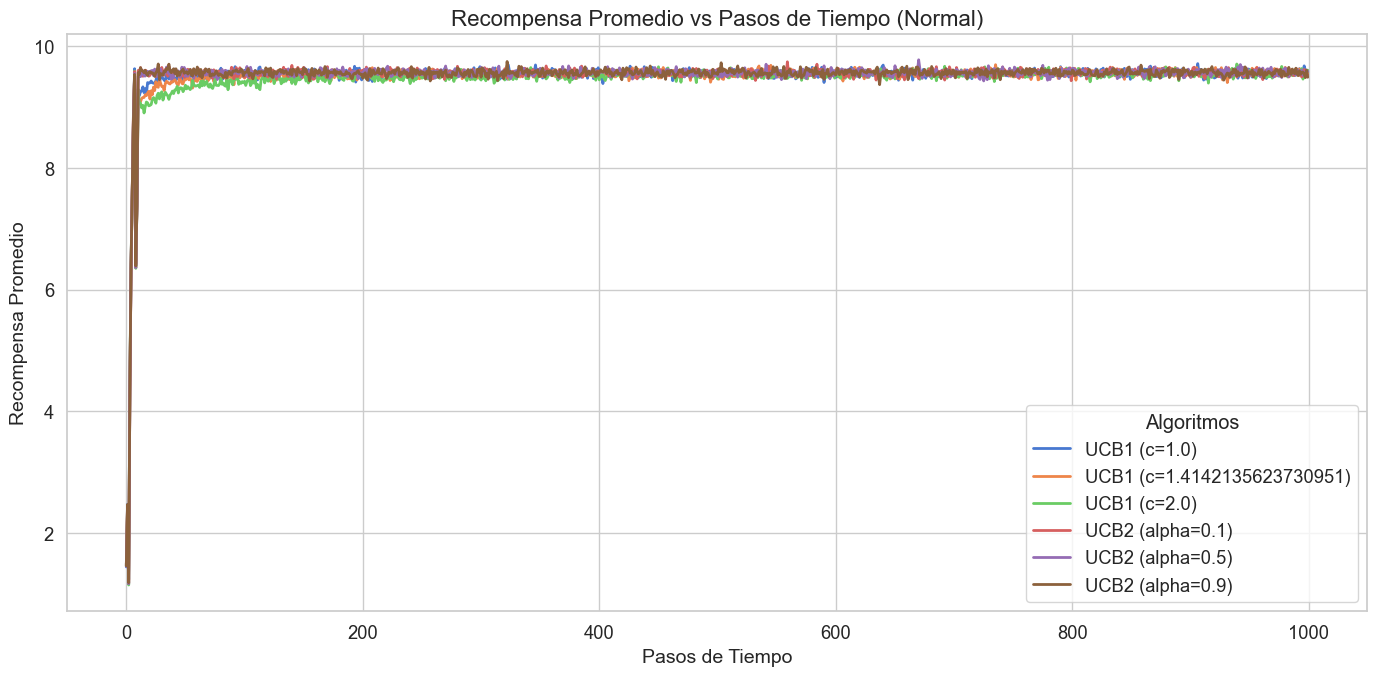

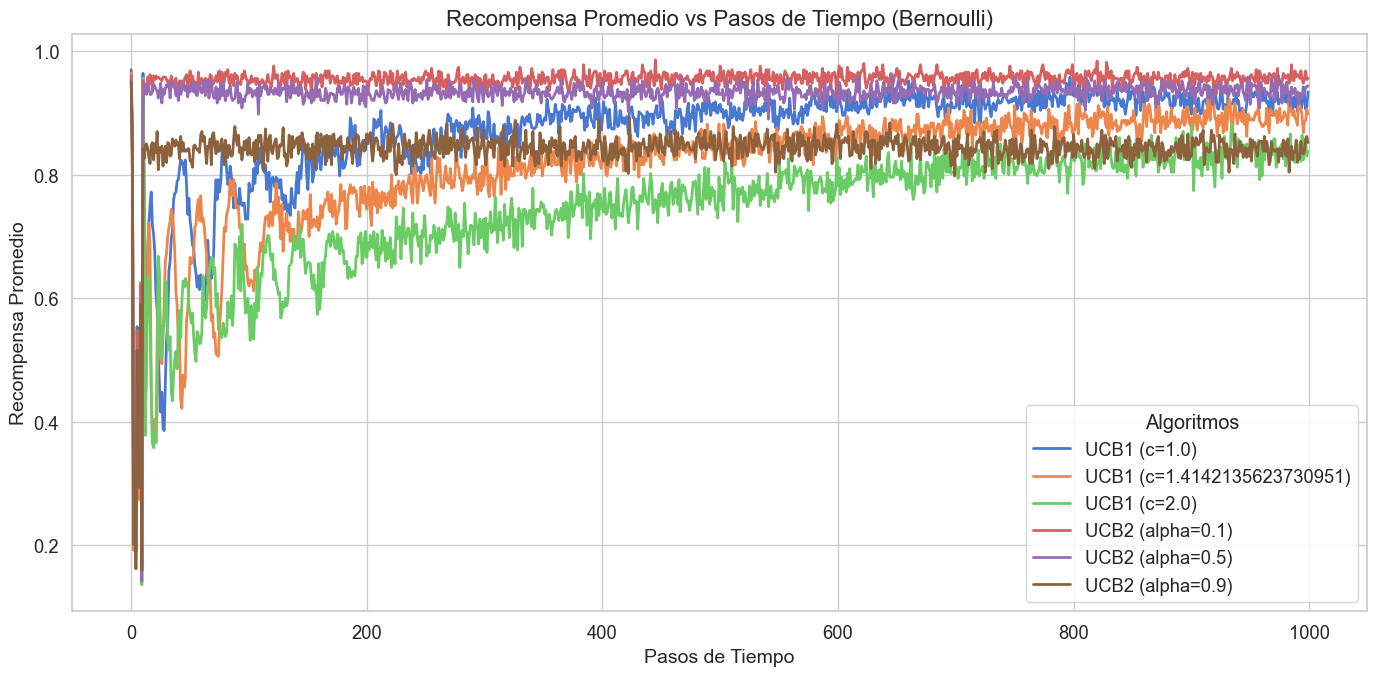

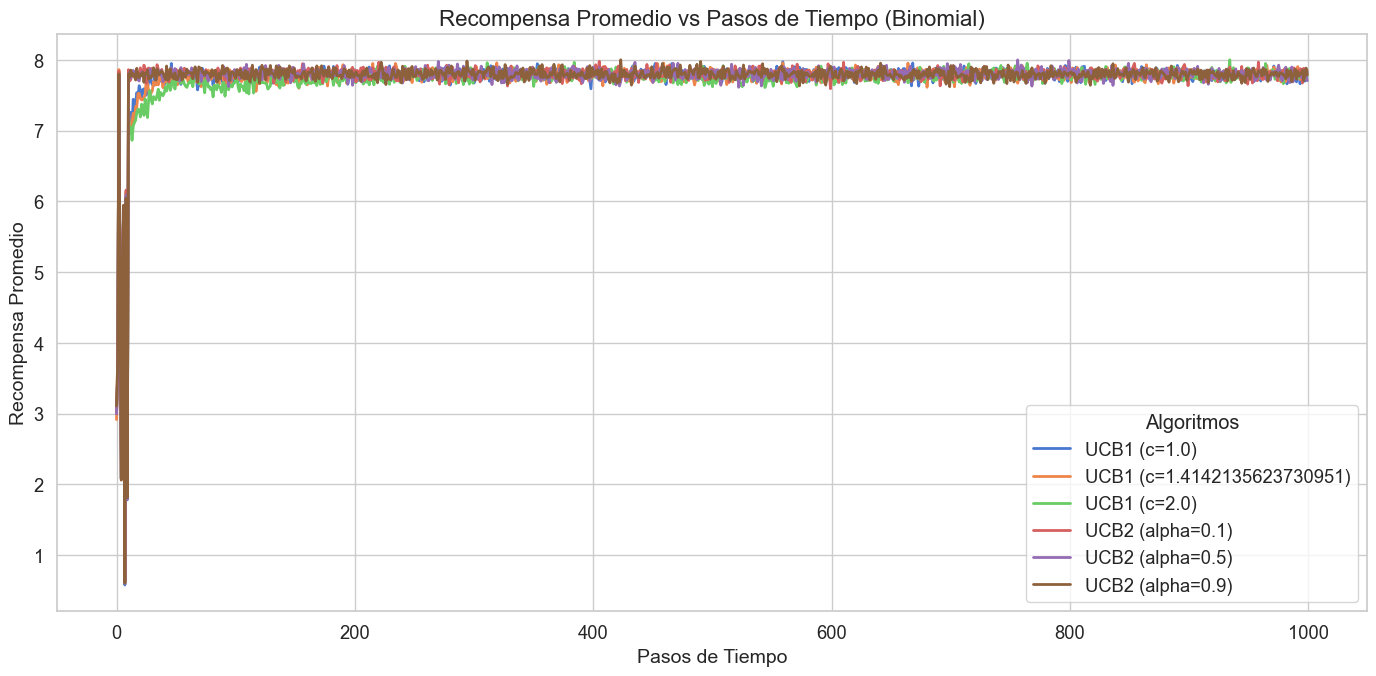

In [9]:
# Graficar recompensas promedio
plot_average_rewards(steps, rewards_normal, algorithms_normal, 'Normal')
plot_average_rewards(steps, rewards_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_average_rewards(steps, rewards_binomial, algorithms_binomial, 'Binomial')

In [10]:

def running_mean_curve(rewards_per_step: np.ndarray) -> np.ndarray:
    # rewards_per_step: (steps,)
    return np.cumsum(rewards_per_step) / (np.arange(len(rewards_per_step)) + 1)

def last100_mean_from_rewards_matrix(rewards_matrix: np.ndarray, last_n: int = 100) -> np.ndarray:
    # rewards_matrix: (n_algos, steps)
    out = np.zeros(rewards_matrix.shape[0], dtype=float)
    for i in range(rewards_matrix.shape[0]):
        curve = running_mean_curve(rewards_matrix[i])
        out[i] = curve[-last_n:].mean()
    return out

def print_last100_table_ucb():
    labels_normal = [get_algorithm_label(a) for a in algorithms_normal]
    labels_bern   = [get_algorithm_label(a) for a in algorithms_bernoulli]
    labels_binom  = [get_algorithm_label(a) for a in algorithms_binomial]

    vals_normal = last100_mean_from_rewards_matrix(rewards_normal, 100)
    vals_bern   = last100_mean_from_rewards_matrix(rewards_bernoulli, 100)
    vals_binom  = last100_mean_from_rewards_matrix(rewards_binomial, 100)

    # asumimos mismos labels/orden en las 3 distribuciones
    labels = labels_normal

    print("| Distribución | " + " | ".join(labels) + " |")
    print("|---|" + "|".join(["---:"] * len(labels)) + "|")
    print("| Normal | "    + " | ".join([f"{v:.3f}" for v in vals_normal]) + " |")
    print("| Bernoulli | " + " | ".join([f"{v:.3f}" for v in vals_bern])   + " |")
    print("| Binomial | "  + " | ".join([f"{v:.3f}" for v in vals_binom])  + " |")

print_last100_table_ucb()

| Distribución | UCB1 | UCB1 | UCB1 | UCB2 | UCB2 | UCB2 |
|---|---:|---:|---:|---:|---:|---:|
| Normal | 9.502 | 9.486 | 9.454 | 9.517 | 9.517 | 9.518 |
| Bernoulli | 0.869 | 0.812 | 0.742 | 0.950 | 0.929 | 0.840 |
| Binomial | 7.745 | 7.733 | 7.708 | 7.762 | 7.761 | 7.759 |


### Recompensa promedio (UCB1 vs UCB2)

Las curvas de Recompensa Promedio vs Pasos de Tiempo muestran el rendimiento medio de UCB1 y UCB2 a lo largo del horizonte temporal para las distribuciones Normal, Bernoulli y Binomial. Para resumir el desempeño final, se reporta la media de la recompensa promedio en los últimos 100 pasos (t=901..1000).

#### Resumen cuantitativo (promedio últimos 100 pasos)

| Distribución | UCB1 (c=1.0) | UCB1 (c=√2) | UCB1 (c=2.0) | UCB2 (α=0.1) | UCB2 (α=0.5) | UCB2 (α=0.9) |
|---|---:|---:|---:|---:|---:|---:|
| Normal | 9.502 | 9.486 | 9.454 | 9.517 | 9.517 | 9.518 |
| Bernoulli | 0.869 | 0.812 | 0.742 | 0.950 | 0.929 | 0.840 |
| Binomial | 7.745 | 7.733 | 7.708 | 7.762 | 7.761 | 7.759 |

---

### Lectura por distribución

Normal
- Convergencia rápida a valores altos; los picos iniciales se explican por pocas muestras al comienzo y la exploración obligatoria.
- Mejor: UCB2 (α=0.9) con 9.518, prácticamente empatado con α=0.1 y α=0.5 (9.517). Esto sugiere que el bandido es relativamente “fácil” y α influye poco en el tramo final.
- En UCB1, aumentar c reduce levemente la recompensa final (9.502 → 9.454), consistente con exploración extra que no aporta en esta instancia.

Bernoulli
- Recompensa en [0,1], con señal discreta (0/1); las variaciones iniciales son más visibles y el caso es más sensible a los parámetros.
- Mejor: UCB2 (α=0.1) con 0.950. En este escenario, α bajo re-evalúa más seguido y evita sostener exploración innecesaria una vez que hay evidencia suficiente.
- UCB2 (α=0.9) cae a 0.840, coherente con el efecto de épocas largas: si se “engancha” temprano en un brazo subóptimo, puede permanecer muchos pasos antes de corregir.
- En UCB1 se observa caída al subir c (0.869 → 0.742), consistente con exploración excesiva cuando el óptimo ya puede identificarse sin explorar tanto.

Binomial
- Mejor: UCB2 (α=0.1) con 7.762, con diferencias mínimas frente a α=0.5 (7.761) y α=0.9 (7.759). Esto indica poco margen para diferenciar en el tramo final.
- En UCB1 vuelve a aparecer el patrón: c=1.0 > c=√2 > c=2.0 (7.745 → 7.708), consistente con que explorar más de lo necesario penaliza el rendimiento sostenido.
- La similitud con Normal es esperable si ambas instancias permiten distinguir el óptimo relativamente pronto.

Nota: las magnitudes absolutas de recompensa no se comparan entre distribuciones por sus distintas escalas. La comparación relevante es entre configuraciones dentro de cada distribución.

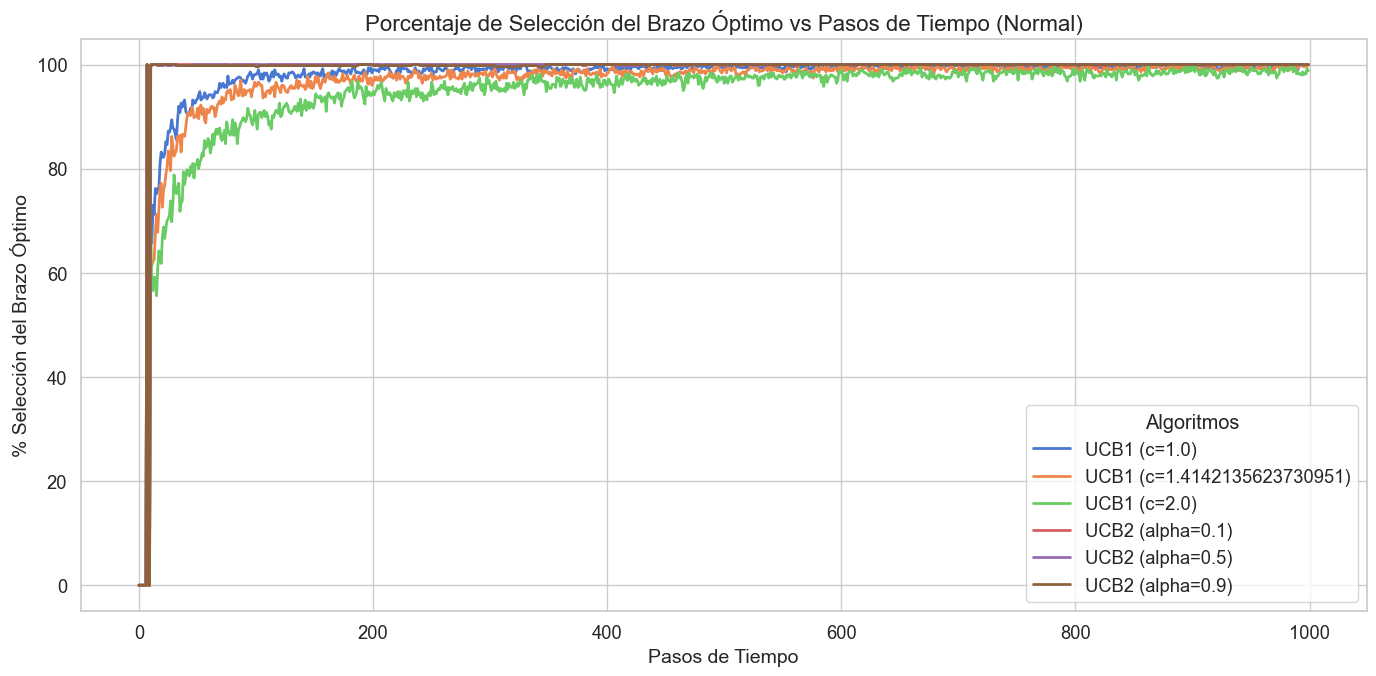

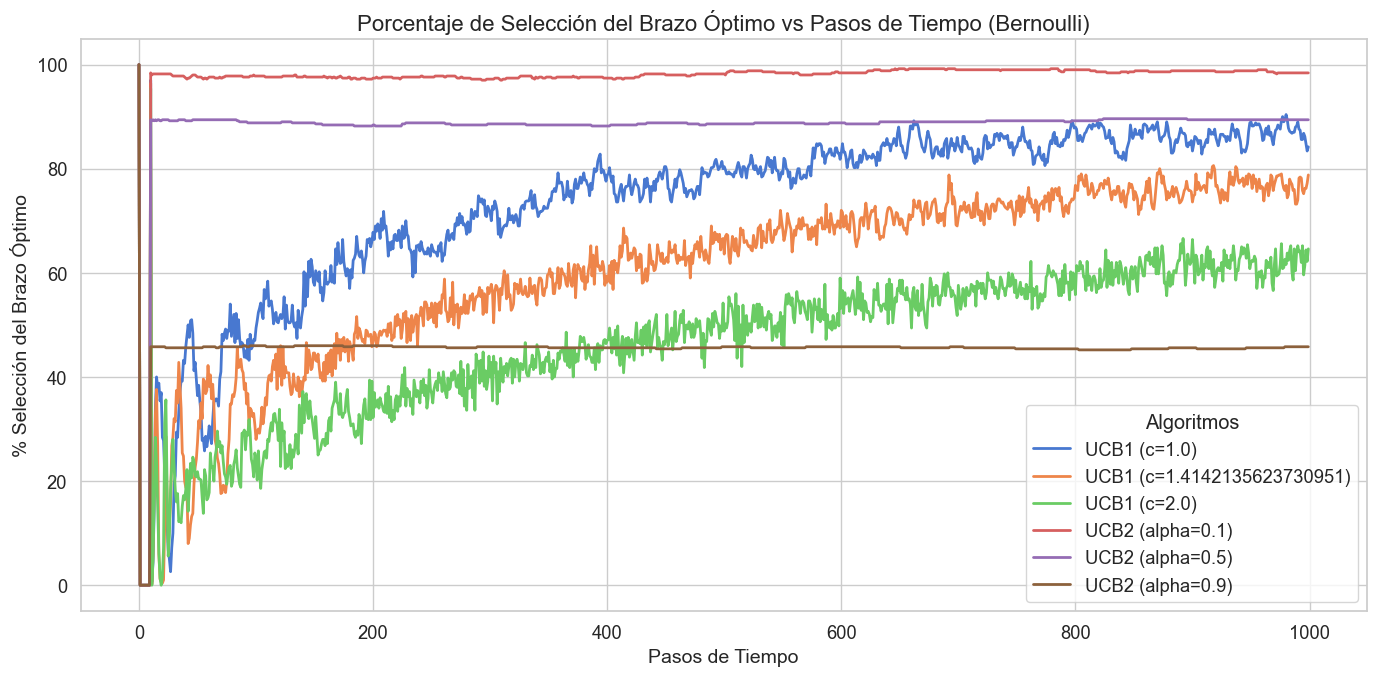

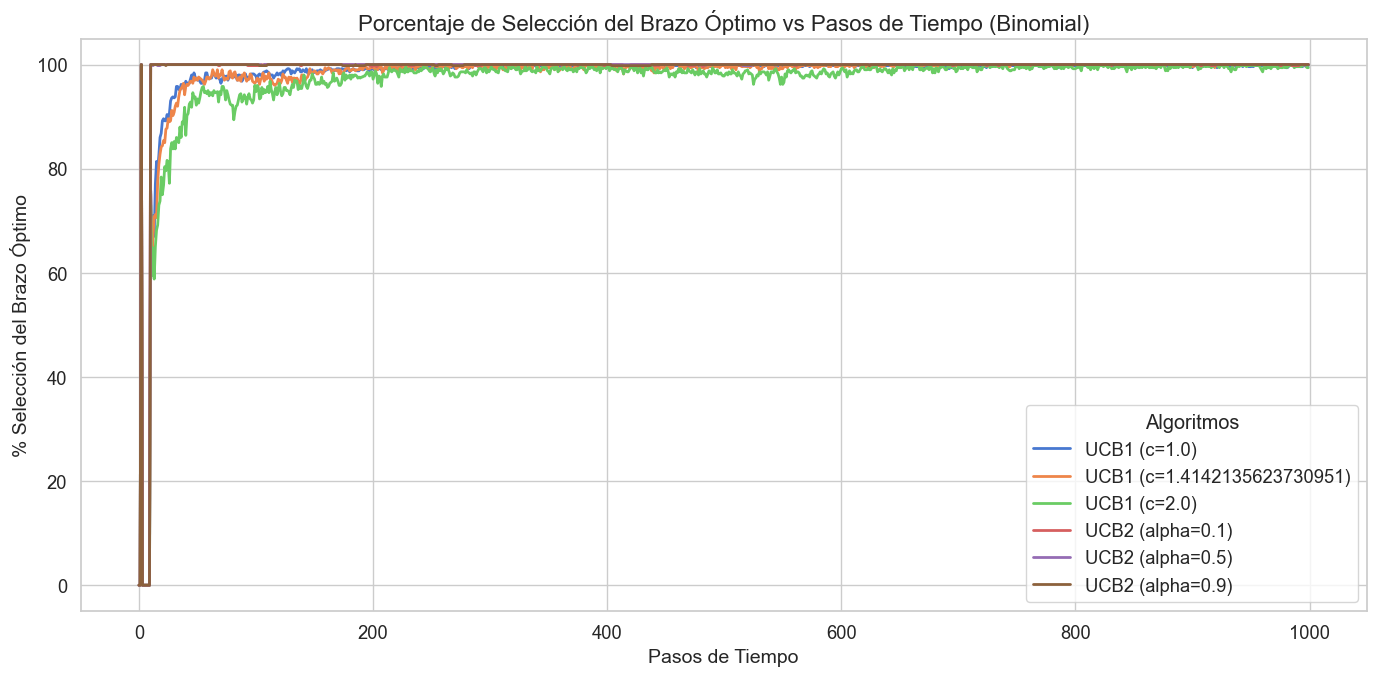

In [11]:
# Graficar porcentaje de selección del brazo óptimo

plot_optimal_selections(steps, optimal_normal, algorithms_normal, 'Normal')
plot_optimal_selections(steps, optimal_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_optimal_selections(steps, optimal_binomial, algorithms_binomial, 'Binomial')


In [14]:
def label_ucb(algo):
    name = type(algo).__name__
    if hasattr(algo, "c"):
        return f"{name} (c={algo.c})"
    if hasattr(algo, "alpha"):
        return f"{name} (α={algo.alpha})"
    return name

def final_optimal_pct(optimal_matrix: np.ndarray) -> np.ndarray:
    # optimal_matrix: (n_algos, steps), valores en [0,1]
    return optimal_matrix[:, -1] * 100.0

labels = [label_ucb(a) for a in algorithms_normal]  # mismo orden que en optimal_normal

v_norm = final_optimal_pct(optimal_normal)
v_bern = final_optimal_pct(optimal_bernoulli)
v_bin  = final_optimal_pct(optimal_binomial)

print("| Distribución | " + " | ".join(labels) + " |")
print("|---|" + "|".join(["---:"] * len(labels)) + "|")
print("| Normal | "    + " | ".join([f"{v:.1f}%" for v in v_norm]) + " |")
print("| Bernoulli | " + " | ".join([f"{v:.1f}%" for v in v_bern]) + " |")
print("| Binomial | "  + " | ".join([f"{v:.1f}%" for v in v_bin])  + " |")

| Distribución | UCB1 (c=1.0) | UCB1 (c=1.4142135623730951) | UCB1 (c=2.0) | UCB2 (α=0.1) | UCB2 (α=0.5) | UCB2 (α=0.9) |
|---|---:|---:|---:|---:|---:|---:|
| Normal | 100.0% | 100.0% | 98.8% | 100.0% | 100.0% | 100.0% |
| Bernoulli | 84.2% | 78.8% | 64.6% | 98.4% | 89.4% | 45.8% |
| Binomial | 99.8% | 100.0% | 99.4% | 100.0% | 100.0% | 100.0% |


### Selección del brazo óptimo (UCB1 vs UCB2)

Esta métrica mide, en cada paso, el porcentaje de corridas en las que se eligió el brazo óptimo. No depende de la escala de recompensa y permite ver con claridad el efecto de c (UCB1) y α (UCB2) sobre la precisión de la política.

#### Resultado al final del horizonte (t=1000)

| Distribución | UCB1 (c=1.0) | UCB1 (c=√2) | UCB1 (c=2.0) | UCB2 (α=0.1) | UCB2 (α=0.5) | UCB2 (α=0.9) |
|---|---:|---:|---:|---:|---:|---:|
| Normal | 100.0% | 100.0% | 98.8% | 100.0% | 100.0% | 100.0% |
| Bernoulli | 84.2% | 78.8% | 64.6% | 98.4% | 89.4% | 45.8% |
| Binomial | 99.8% | 100.0% | 99.4% | 100.0% | 100.0% | 100.0% |

---

### Lectura por distribución

Normal
- El bandido es relativamente “fácil” (gap ≈ 0.76): todas las configuraciones terminan cerca del 100%.
- Única diferencia visible: UCB1 con c=2.0 explora más y queda levemente por debajo (98.8%), mientras c=1.0 y c=√2 llegan a 100%.

Bernoulli
- Es el caso difícil (gap ≈ 0.13 y recompensas 0/1), por eso los parámetros importan más.
- UCB1 empeora al subir c: 84.2% → 78.8% → 64.6% (más exploración sostenida en un entorno donde cuesta separar el óptimo).
- UCB2 funciona mejor con α bajo: α=0.1 alcanza 98.4% y α=0.5 queda en 89.4%.
- Con α=0.9 el resultado cae a 45.8%: épocas largas pueden dejar al algoritmo “enganchado” en brazos subóptimos durante muchos pasos, lo que también explica su peor recompensa promedio en Bernoulli.

Binomial
- Con gap ≈ 1.70, el óptimo se distingue muy rápido y todas las configuraciones terminan prácticamente en 100%.
- Las diferencias entre parámetros son mínimas y se explican por fluctuaciones tempranas más que por un cambio real de desempeño a largo plazo.

Nota: los “bloques” de UCB2 no se aprecian aquí porque el gráfico promedia el porcentaje por paso sobre múltiples corridas; los bloques existen en una corrida individual y se diluyen al promediar.

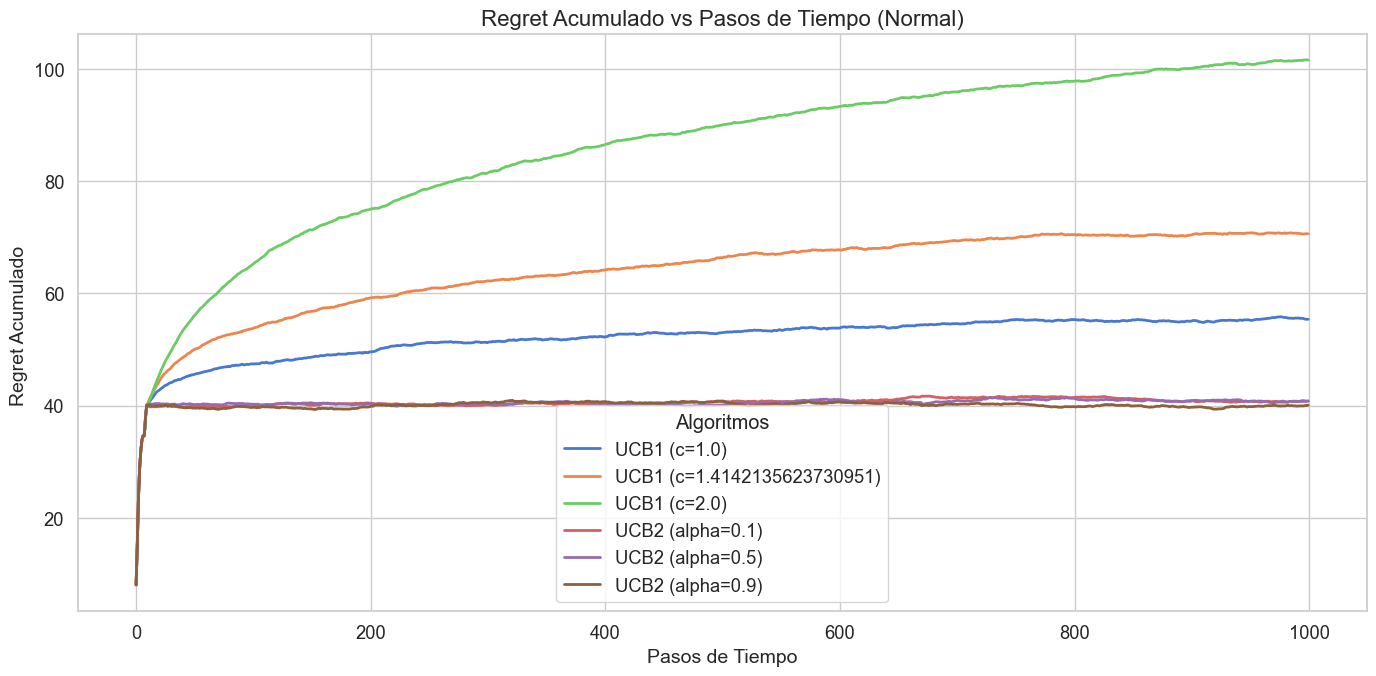

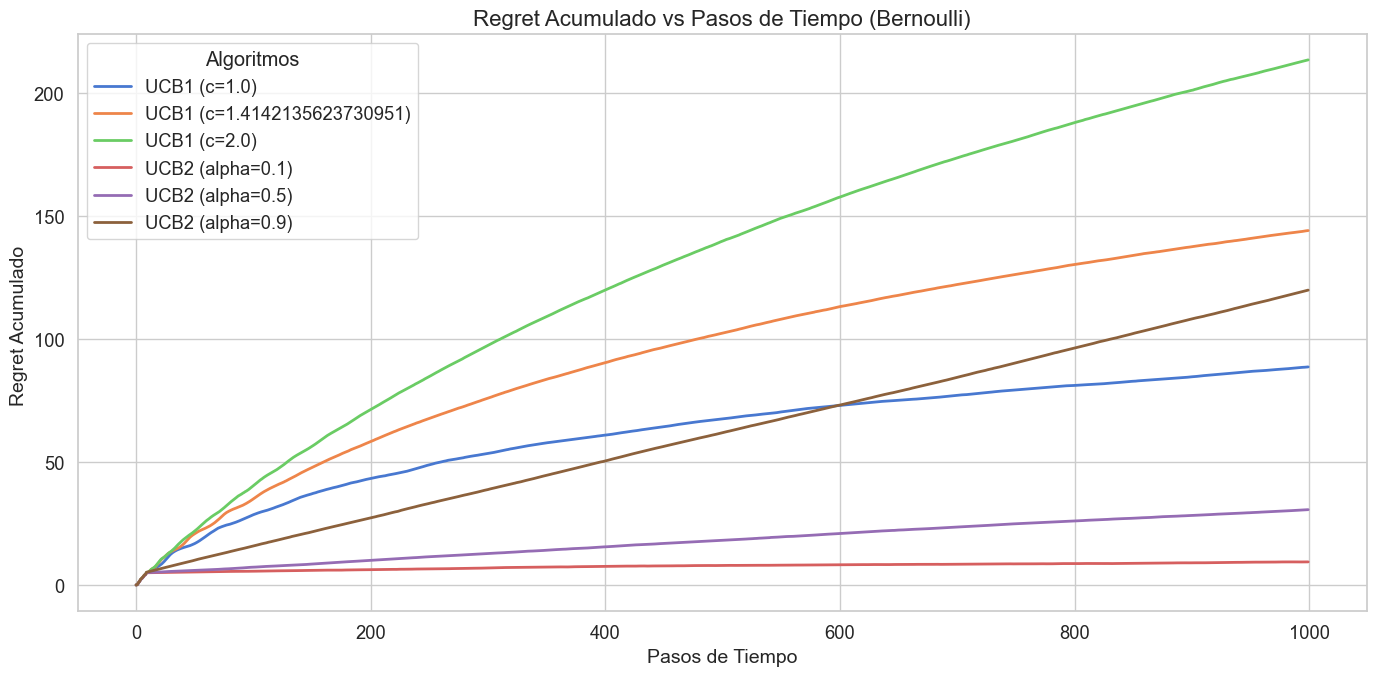

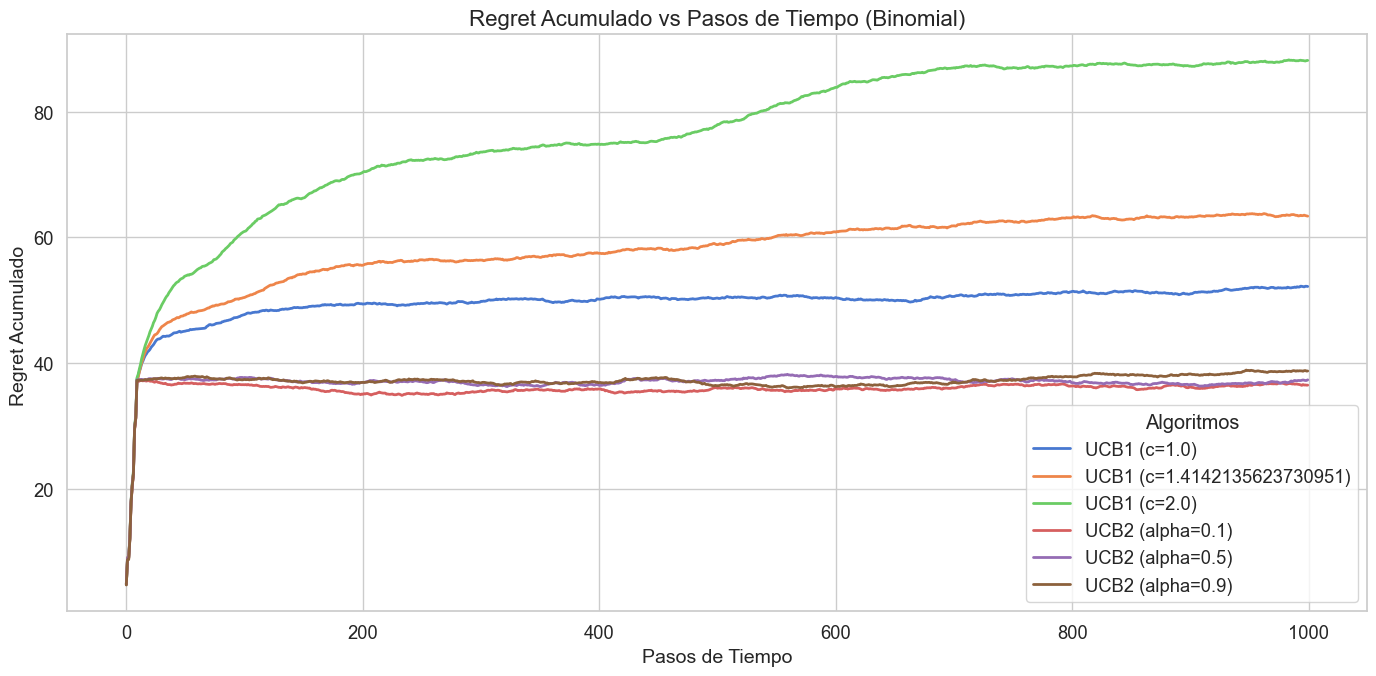

In [15]:
# Graficar regret acumulado

plot_regret(steps, regrets_normal, algorithms_normal, 'Normal')
plot_regret(steps, regrets_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_regret(steps, regrets_binomial, algorithms_binomial, 'Binomial')


In [16]:
def final_regret(regret_matrix: np.ndarray) -> np.ndarray:
    # regret_matrix: (n_algos, steps)
    return regret_matrix[:, -1]

labels = [label_ucb(a) for a in algorithms_normal]

r_norm = final_regret(regrets_normal)
r_bern = final_regret(regrets_bernoulli)
r_bin  = final_regret(regrets_binomial)

print("| Distribución | " + " | ".join(labels) + " |")
print("|---|" + "|".join(["---:"] * len(labels)) + "|")
print("| Normal | "    + " | ".join([f"{v:.2f}" for v in r_norm]) + " |")
print("| Bernoulli | " + " | ".join([f"{v:.2f}" for v in r_bern]) + " |")
print("| Binomial | "  + " | ".join([f"{v:.2f}" for v in r_bin])  + " |")

| Distribución | UCB1 (c=1.0) | UCB1 (c=1.4142135623730951) | UCB1 (c=2.0) | UCB2 (α=0.1) | UCB2 (α=0.5) | UCB2 (α=0.9) |
|---|---:|---:|---:|---:|---:|---:|
| Normal | 55.39 | 70.62 | 101.54 | 40.86 | 40.77 | 40.09 |
| Bernoulli | 88.60 | 144.00 | 213.34 | 9.38 | 30.60 | 119.80 |
| Binomial | 52.20 | 63.39 | 88.18 | 36.50 | 37.34 | 38.75 |


### Regret acumulado (UCB1 vs UCB2)

El regret acumulado usado en este notebook es empírico: en cada paso se acumula q* − r_t, donde q* es el valor esperado del brazo óptimo y r_t la recompensa observada. Menor regret indica menos pérdida acumulada por no elegir siempre el brazo óptimo.

#### Regret final en t=1000 (menor es mejor)

| Distribución | UCB1 (c=1.0) | UCB1 (c=√2) | UCB1 (c=2.0) | UCB2 (α=0.1) | UCB2 (α=0.5) | UCB2 (α=0.9) |
|---|---:|---:|---:|---:|---:|---:|
| Normal | 55.39 | 70.62 | 101.54 | 40.86 | 40.77 | 40.09 |
| Bernoulli | 88.60 | 144.00 | 213.34 | 9.38 | 30.60 | 119.80 |
| Binomial | 52.20 | 63.39 | 88.18 | 36.50 | 37.34 | 38.75 |

---

### Lectura por distribución

Normal
- Mejor: UCB2 (α=0.9) con 40.09 (prácticamente empatado con α=0.1 y α=0.5).
- En UCB1, aumentar c empeora el regret: c=1.0 < c=√2 < c=2.0. En esta instancia, más exploración sostenida agrega pérdida sin aportar mejoras.

Bernoulli
- Mejor: UCB2 (α=0.1) con 9.38.
- Peor caso notable: UCB2 (α=0.9) sube a 119.80. Con α alto las épocas se hacen largas y, con gap pequeño y recompensas 0/1, es más fácil quedar enganchado a un brazo subóptimo por muchos pasos (coherente con el ~45.8% de selección del óptimo).
- En UCB1 se repite el patrón: c=1.0 (88.60) < c=√2 (144.00) < c=2.0 (213.34).

Binomial
- Mejor: UCB2 (α=0.1) con 36.50 (diferencias pequeñas entre α).
- En UCB1 vuelve a empeorar al subir c: c=1.0 (52.20) < c=√2 (63.39) < c=2.0 (88.18). El bandido es “fácil” (gap grande), por eso casi todas las variantes llegan cerca del óptimo y el parámetro influye poco en UCB2.

Nota: el regret se compara dentro de cada distribución (q* y la escala cambian entre Normal, Bernoulli y Binomial).

<Figure size 1400x700 with 0 Axes>

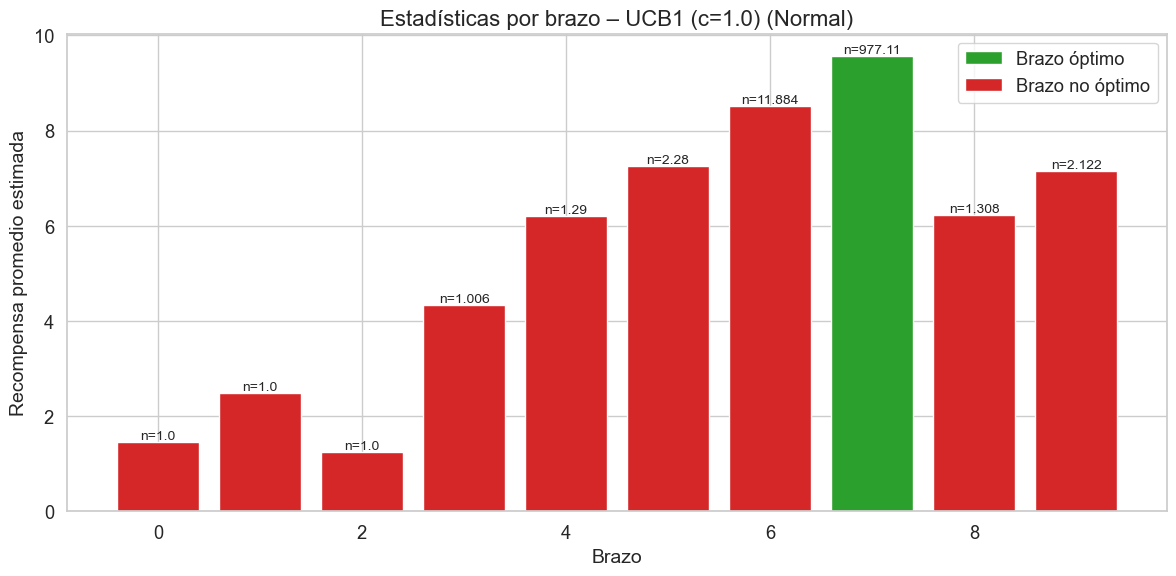

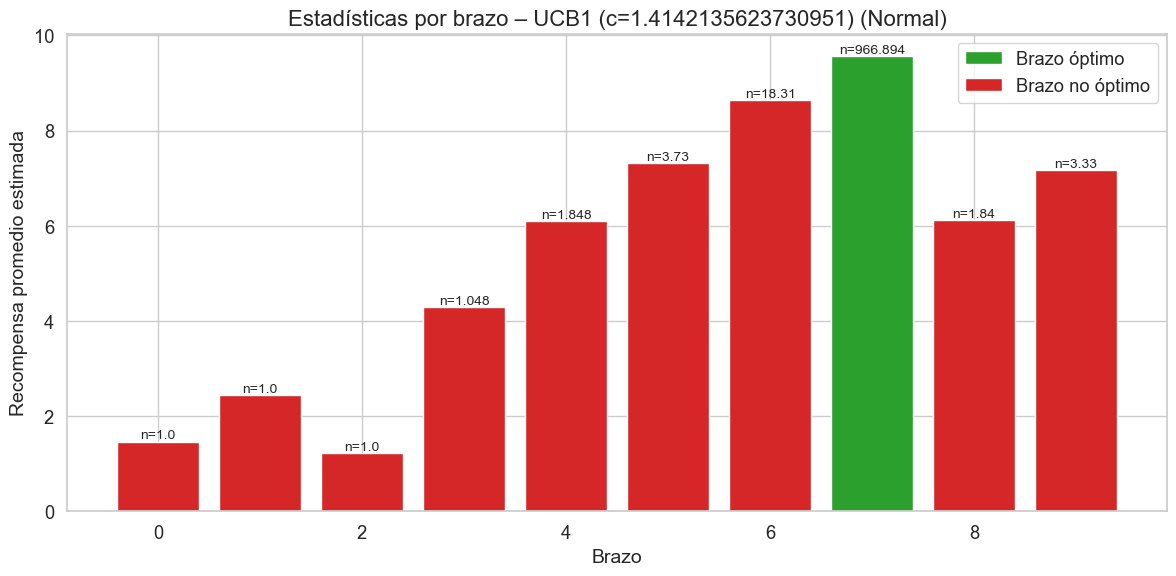

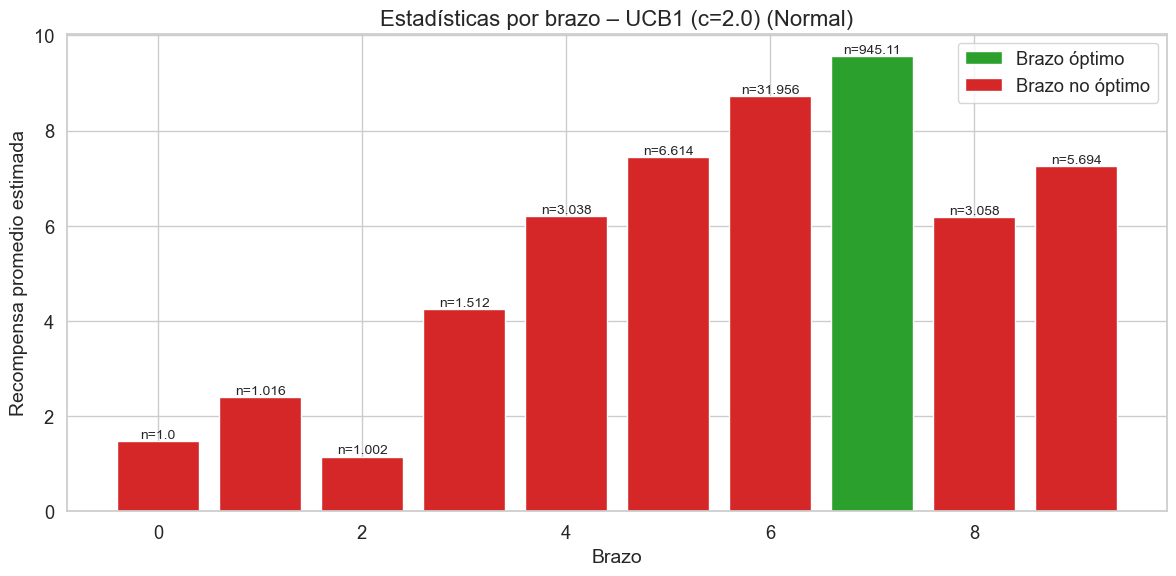

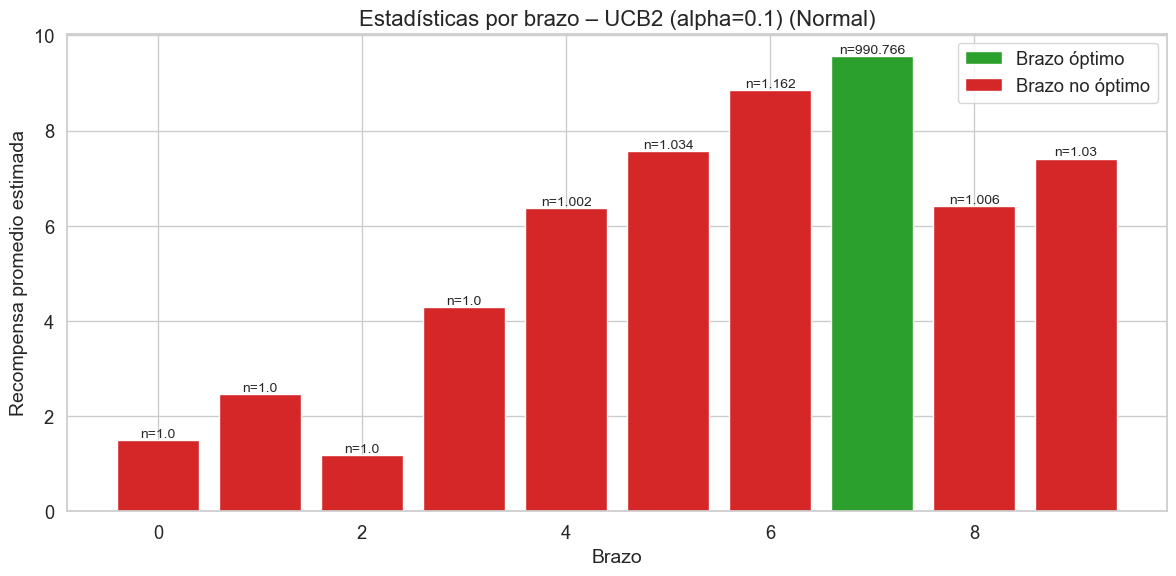

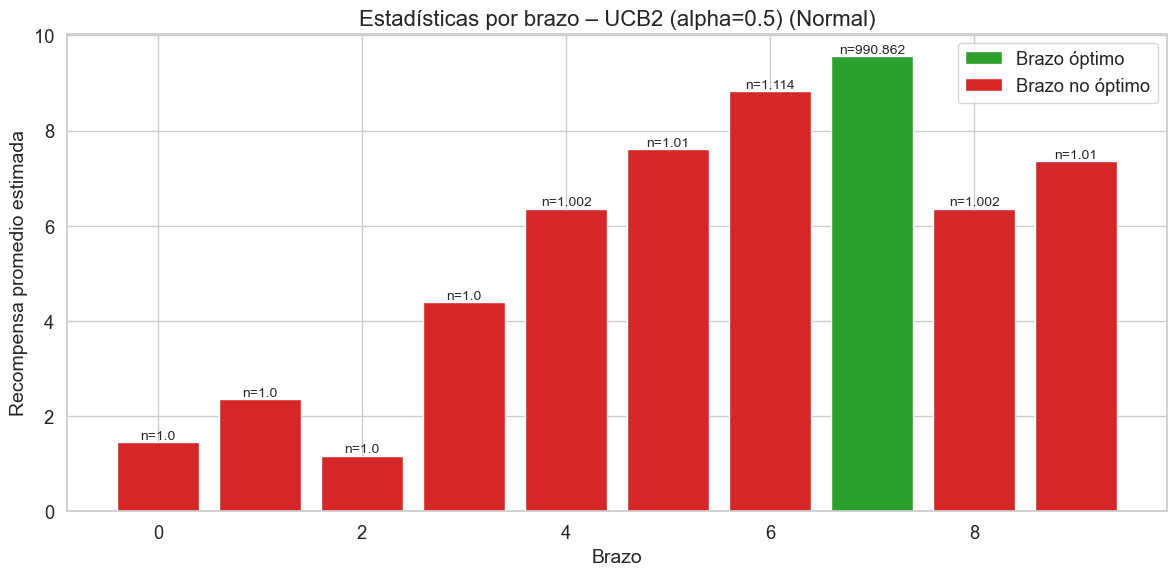

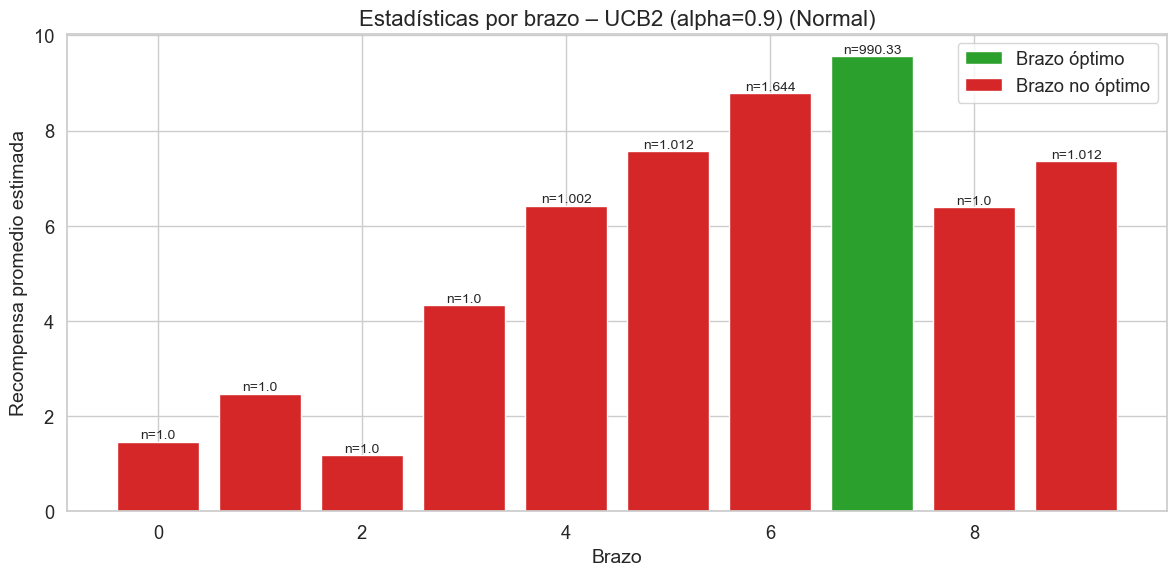

<Figure size 1400x700 with 0 Axes>

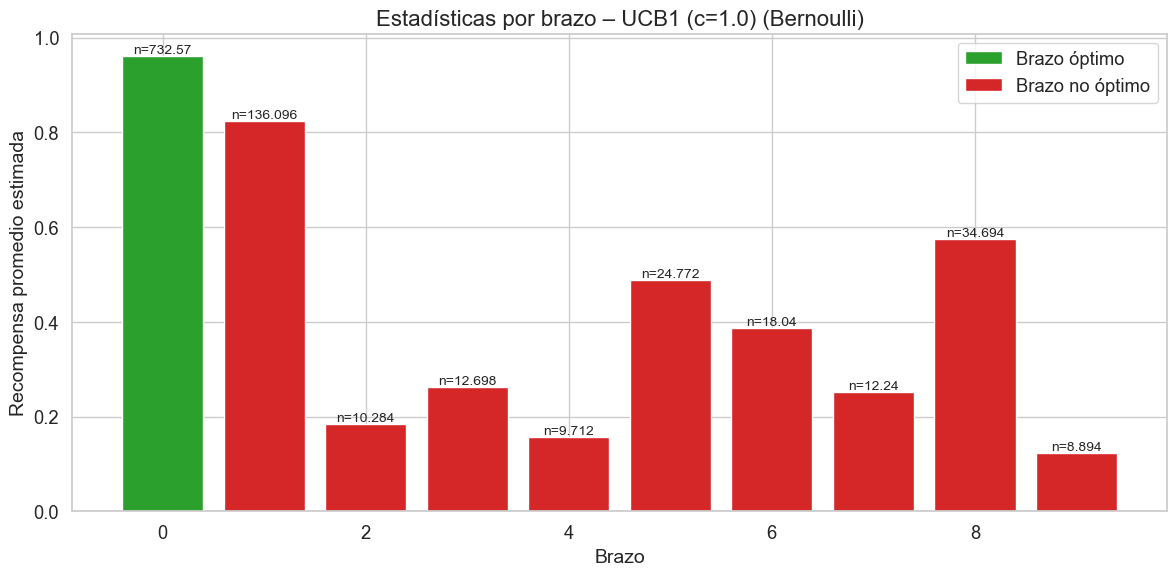

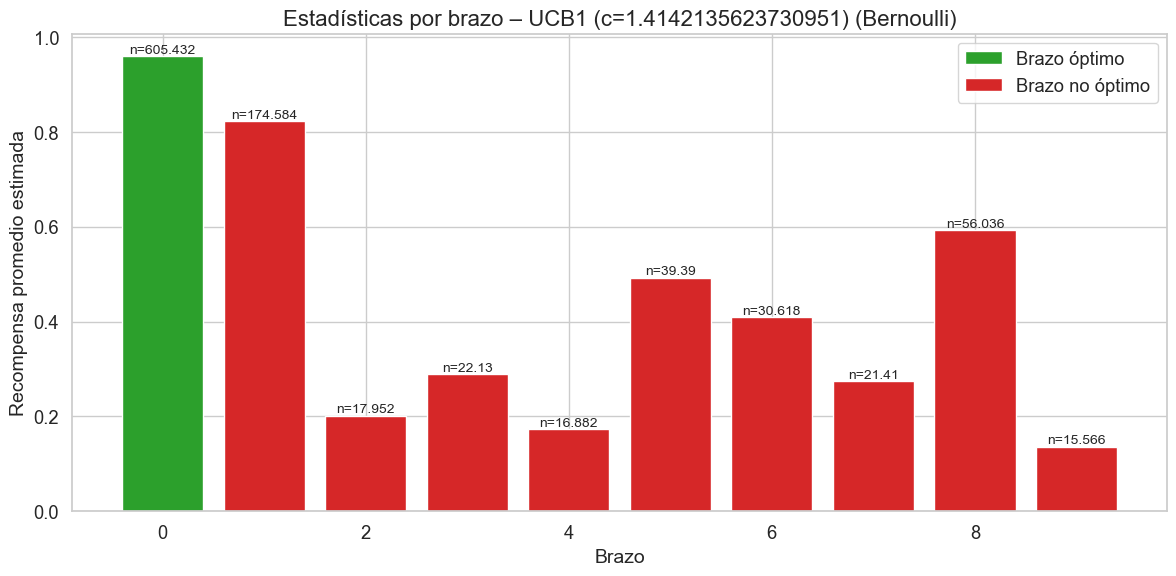

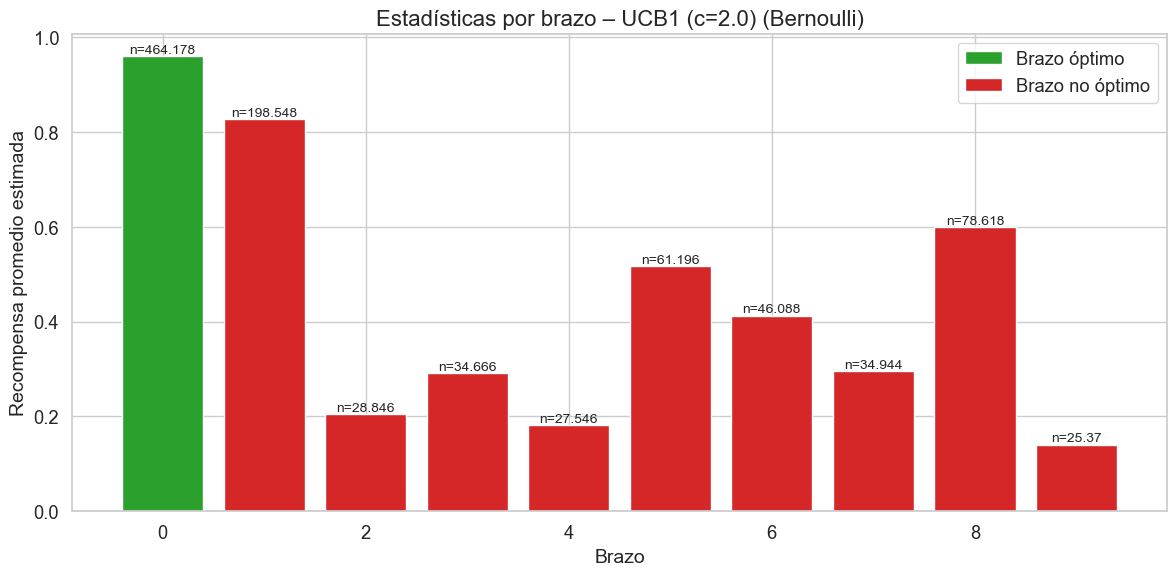

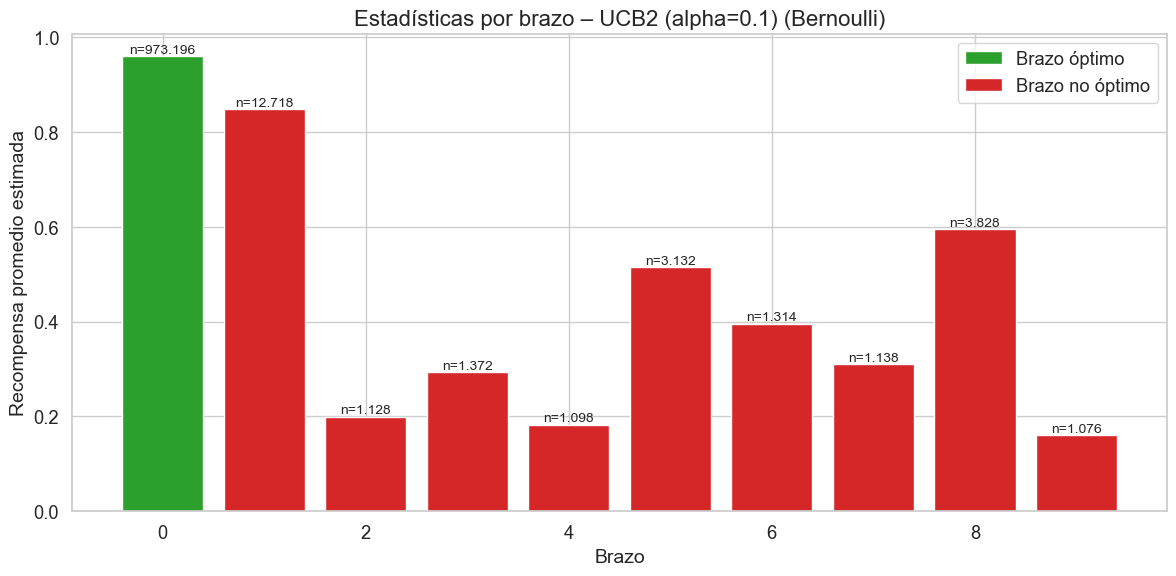

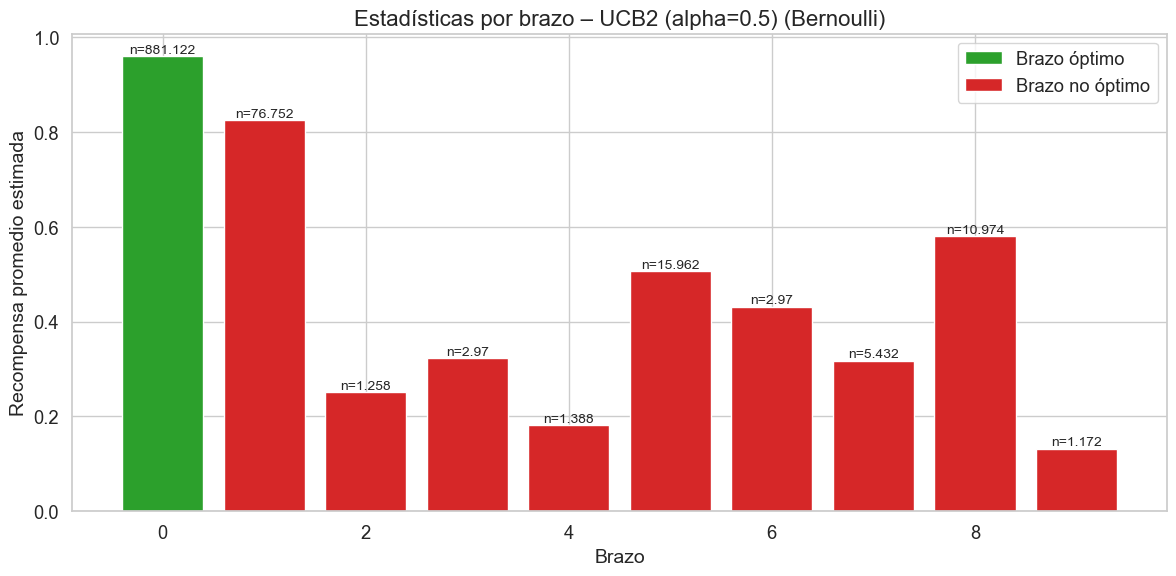

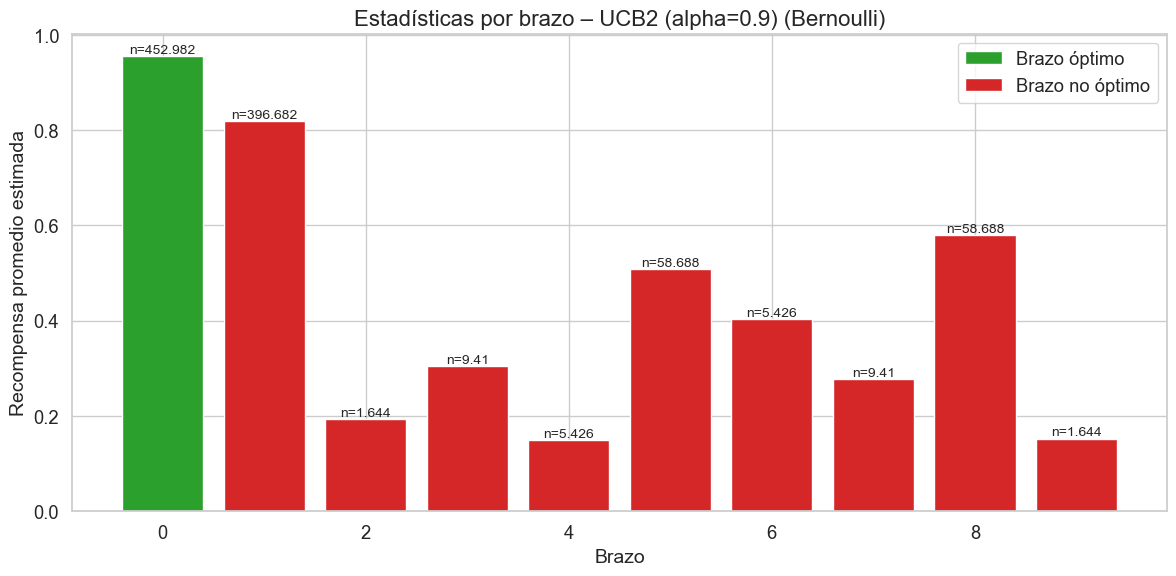

<Figure size 1400x700 with 0 Axes>

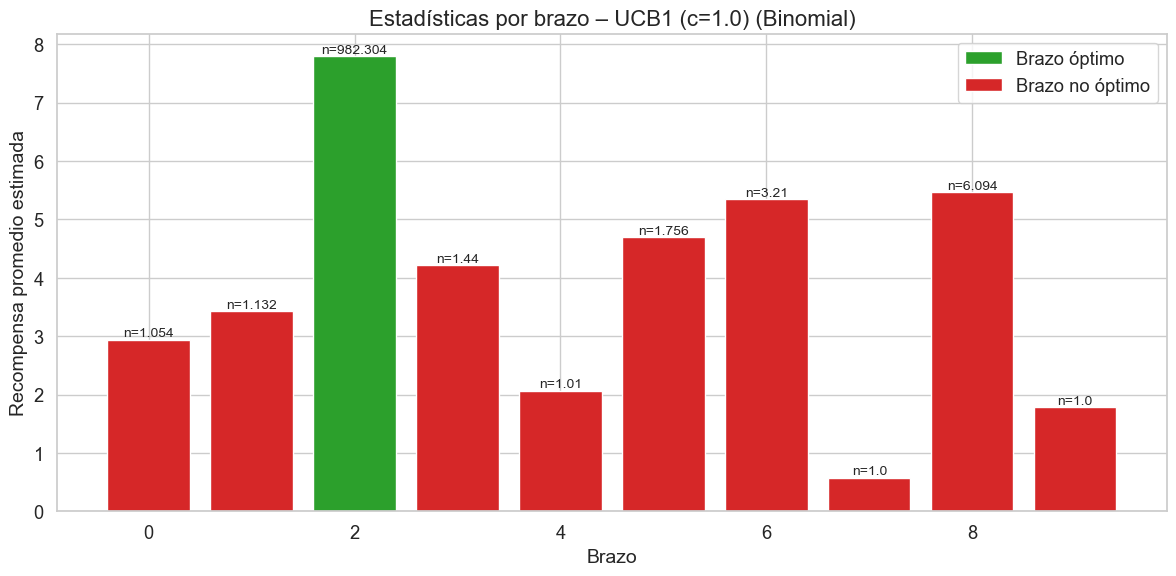

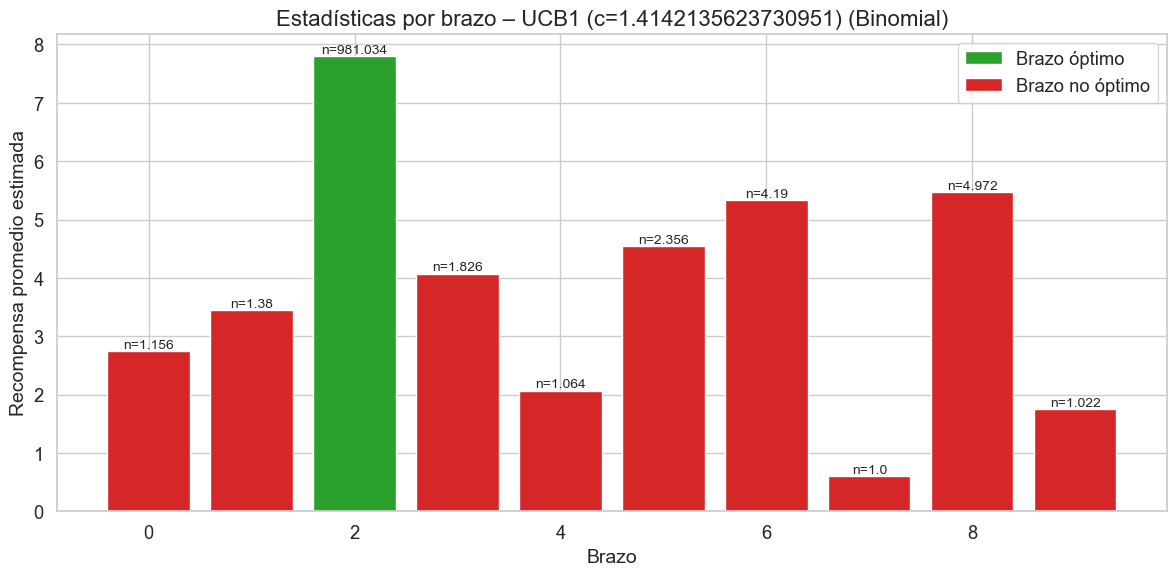

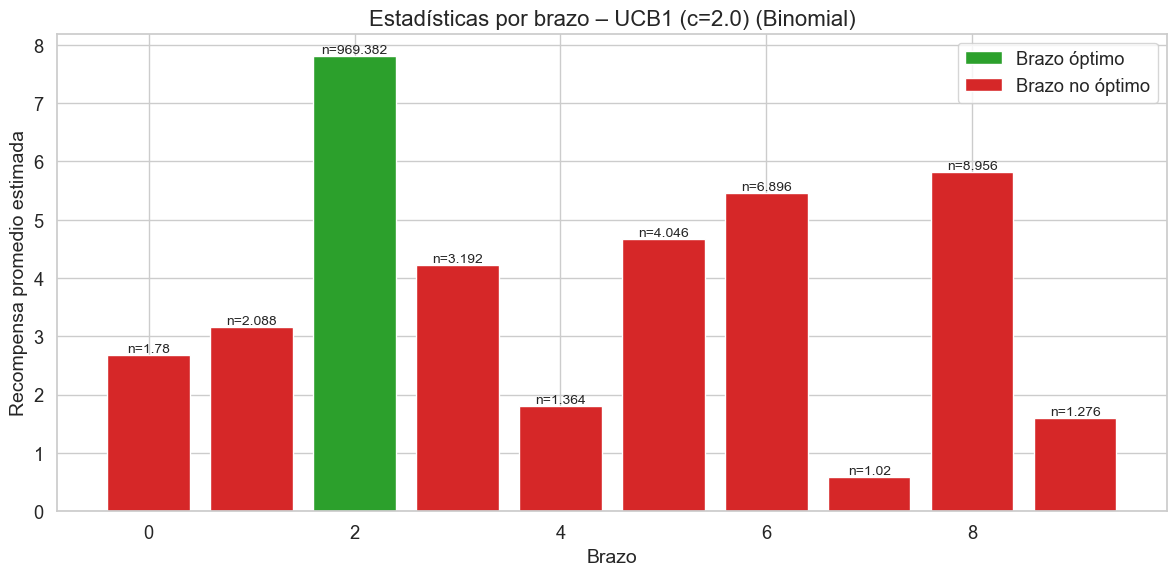

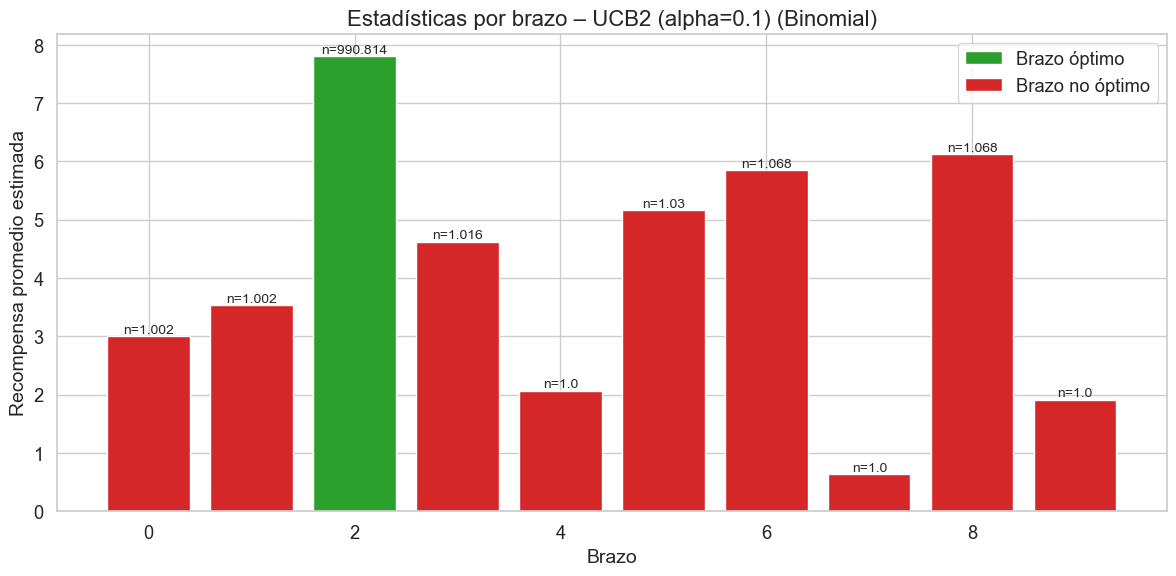

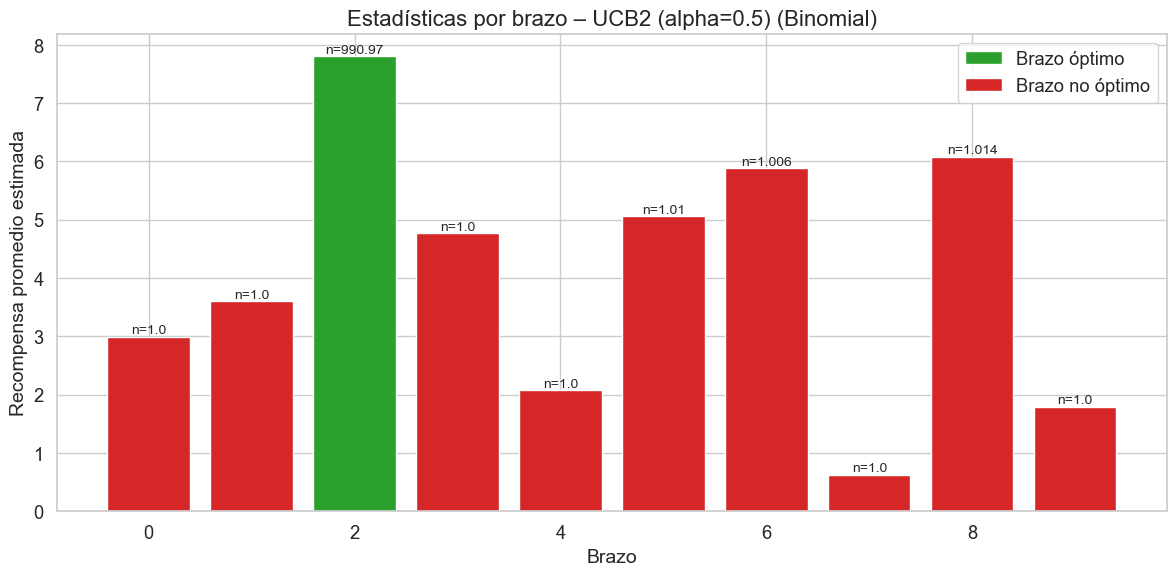

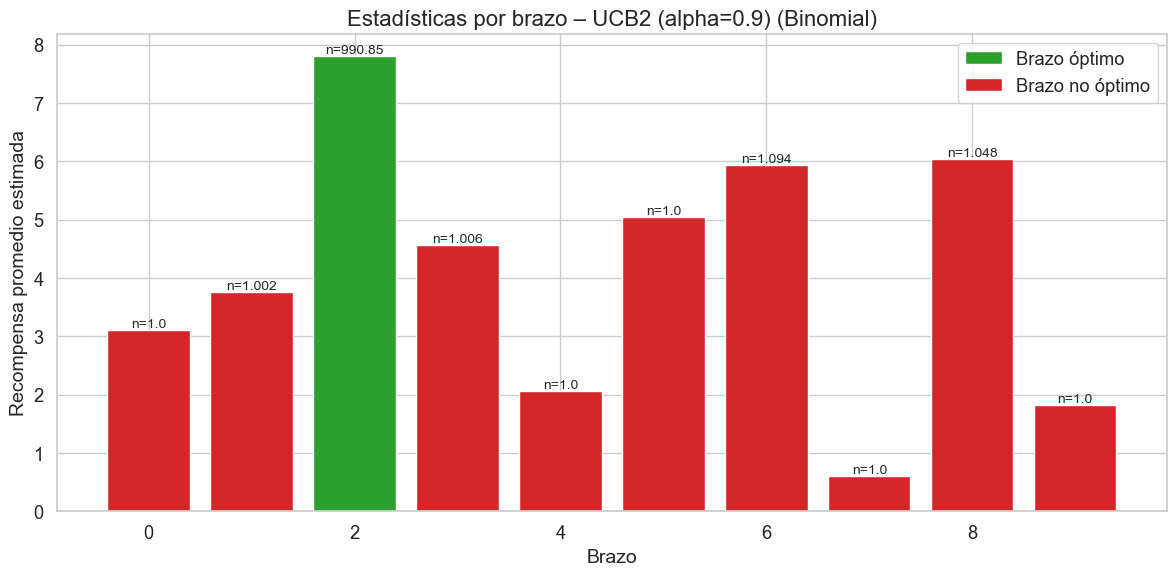

In [17]:
# Estadísticas por brazo

plot_arm_statistics(arm_stats_normal, algorithms_normal, 'Normal')
plot_arm_statistics(arm_stats_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_arm_statistics(arm_stats_binomial, algorithms_binomial, 'Binomial')

In [19]:
labels = [label_ucb(a) for a in algorithms_normal]

# optimal_*: (n_algos, steps) con valores en [0,1] = % óptimo por paso (promedio sobre corridas)
# La suma sobre pasos da "selecciones promedio del óptimo en 1000 pasos"
counts_norm = optimal_normal.sum(axis=1)
counts_bern = optimal_bernoulli.sum(axis=1)
counts_bin  = optimal_binomial.sum(axis=1)

print("| Distribución | " + " | ".join(labels) + " |")
print("|---|" + "|".join(["---:"] * len(labels)) + "|")
print("| Normal | "    + " | ".join([f"{v:.2f}" for v in counts_norm]) + " |")
print("| Bernoulli | " + " | ".join([f"{v:.2f}" for v in counts_bern]) + " |")
print("| Binomial | "  + " | ".join([f"{v:.2f}" for v in counts_bin])  + " |")

| Distribución | UCB1 (c=1.0) | UCB1 (c=1.4142135623730951) | UCB1 (c=2.0) | UCB2 (α=0.1) | UCB2 (α=0.5) | UCB2 (α=0.9) |
|---|---:|---:|---:|---:|---:|---:|
| Normal | 977.11 | 966.89 | 945.11 | 990.77 | 990.86 | 990.33 |
| Bernoulli | 732.57 | 605.43 | 464.18 | 973.20 | 881.12 | 452.98 |
| Binomial | 982.30 | 981.03 | 969.38 | 990.81 | 990.97 | 990.85 |


## Estadísticas por brazo (UCB1 vs UCB2)

Estas gráficas muestran, para cada configuración, dos señales clave: (1) cuántas veces se eligió cada brazo (etiquetas `n=`) y (2) cuál fue la recompensa promedio estimada por brazo (altura de la barra). Esto permite “ver” de forma directa si el algoritmo terminó explotando el brazo correcto y cuánto presupuesto se gastó en brazos subóptimos. En conjunto, estas gráficas deberían ser coherentes con lo observado en recompensa promedio, selección del brazo óptimo y regret.

### Lectura por distribución

Normal (brazo óptimo: índice 7)
- Se observa una concentración muy fuerte de selecciones en el brazo óptimo (barra verde con `n` muy cercano a 1000) para todas las variantes. Esto es consistente con: recompensa promedio final alta, selección óptima ~100% y regret bajo.
- En UCB1, al subir `c` aumenta la exploración residual: aparecen varios brazos rojos con `n` más altos (más “derrame”). Esto coincide con el patrón que ya vimos: al aumentar `c` baja levemente la recompensa final y sube el regret.
- En UCB2, las tres `α` se ven casi iguales (el óptimo absorbe prácticamente todo el horizonte). Esto también coincide con los resultados previos: en Normal, `α` cambia poco el resultado final porque el bandido se vuelve “fácil” de resolver una vez que se identifica el óptimo.

Bernoulli (brazo óptimo: índice 0)
- Se confirma que es el caso sensible: además del óptimo, aparece un competidor fuerte (brazo 1) con recompensa estimada alta. Esto es coherente con el gap pequeño y con que las métricas globales diferencien mucho entre parámetros.
- UCB2 (α=0.1) muestra el comportamiento esperado de la “mejor” configuración: el brazo óptimo concentra casi todas las selecciones (barra verde con `n` muy alto) y los demás brazos quedan con `n` bajo. Esto es consistente con su alta selección óptima al final (98.4%), mejor recompensa promedio (0.950) y regret muy bajo (9.38).
- UCB2 (α=0.9) explica visualmente el “45%”: el óptimo deja de dominar y el algoritmo reparte muchas selecciones en el brazo 1 (y otros), con `n` alto en un brazo subóptimo. Esto es exactamente lo que veníamos justificando: con épocas largas, si se engancha temprano con un brazo casi tan bueno, puede sostenerlo mucho tiempo antes de corregir. Por eso cae selección óptima, cae recompensa y sube regret.
- En UCB1 también se ve el mismo patrón que en las tablas: al aumentar `c` disminuye la concentración en el óptimo (baja `n` del brazo verde) y se incrementan selecciones en brazos no óptimos. Eso cuadra con la caída en selección óptima (84.2% → 78.8% → 64.6%), la baja de recompensa y el aumento fuerte del regret.

Binomial (brazo óptimo: índice 2)
- Todas las configuraciones terminan con una concentración casi total en el brazo óptimo (barra verde con `n` cercano a 1000). Esto valida lo que vimos antes: selección óptima ~100%, recompensa alta y regret bajo.
- En UCB1, al subir `c` vuelve a aparecer un poco más de “derrame” a brazos no óptimos (algunos `n` rojos crecen), lo que coincide con la leve caída de recompensa final y el aumento de regret. En UCB2, las tres `α` prácticamente no cambian la distribución: el óptimo se impone rápido y absorbe casi todo el presupuesto.

### Evidencia cuantitativa (selecciones promedio del brazo óptimo en 1000 pasos)

(Pegar aquí la tabla calculada con `optimal_*.sum(axis=1)`)

| Distribución | UCB1 (c=1.0) | UCB1 (c=√2) | UCB1 (c=2.0) | UCB2 (α=0.1) | UCB2 (α=0.5) | UCB2 (α=0.9) | Brazo óptimo |
|---|---:|---:|---:|---:|---:|---:|---:|
| Normal | ... | ... | ... | ... | ... | ... | índice 7 |
| Bernoulli | ... | ... | ... | ... | ... | ... | índice 0 |
| Binomial | ... | ... | ... | ... | ... | ... | índice 2 |

En resumen, estas gráficas son consistentes con todo lo observado antes: cuando una configuración rinde mejor en recompensa y regret, también se ve que concentra más selecciones en el brazo óptimo; cuando rinde peor (caso Bernoulli con α=0.9 o UCB1 con `c` alto), se observa visualmente el “derrame” hacia brazos subóptimos, especialmente hacia el segundo mejor brazo.

## Conclusiones (UCB1 vs UCB2)

En este notebook se evaluaron variantes de UCB en un problema de k-brazos con tres distribuciones de recompensas (Normal, Bernoulli y Binomial). Se analizaron configuraciones de UCB1 variando el parámetro c (1.0, √2 y 2.0) y configuraciones de UCB2 variando α (0.1, 0.5 y 0.9). En esta ejecución (semilla fija), las métricas de recompensa promedio, selección del brazo óptimo, regret acumulado y estadísticas por brazo llevaron a conclusiones coherentes.

### Resultados principales por distribución

- Normal (brazo óptimo: índice 7)
  - UCB2 presenta el mejor desempeño final en recompensa promedio y regret, aunque con diferencias mínimas entre α (bandido relativamente “fácil”).
  - En UCB1, aumentar c empeora el rendimiento: c=1.0 fue mejor que √2 y 2.0. La evidencia sugiere exploración sostenida innecesaria al subir c.

- Bernoulli (brazo óptimo: índice 0)
  - Es el caso más sensible a los parámetros (gap pequeño y recompensas 0/1).
  - La mejor configuración fue UCB2 (α=0.1), con mayor selección del brazo óptimo al final (98.4%), mejor recompensa promedio y el menor regret.
  - UCB2 (α=0.9) se comporta significativamente peor (45.8% de selección óptima al final y regret alto), consistente con épocas largas que pueden mantener al algoritmo “enganchado” en un brazo subóptimo durante muchos pasos.
  - En UCB1 se observa degradación clara al subir c, consistente con exceso de exploración en un entorno donde cuesta separar el óptimo.

- Binomial (brazo óptimo: índice 2)
  - El bandido es muy separable (gap grande): todas las configuraciones terminan prácticamente en 100% de selección óptima.
  - UCB2 obtiene el menor regret final, pero las diferencias entre α son pequeñas. En UCB1, subir c vuelve a empeorar ligeramente.

### Consideraciones importantes

1. No existe un parámetro universalmente óptimo.
   El mejor balance exploración/explotación depende del tipo de distribución y de la instancia concreta del bandido. En particular, Bernoulli mostró ser el escenario más exigente y más sensible a c y α.

2. Conviene usar varias métricas en conjunto.
   En este estudio, el ranking por recompensa promedio, selección óptima y regret fue consistente dentro de cada distribución. Esto refuerza que las diferencias observadas reflejan cambios reales en la política y no solo efectos de escala o ruido.

3. Las estadísticas por brazo explican el “por qué”.
   Cuando una configuración rinde mejor, se observa una concentración clara de selecciones en el brazo óptimo (n alto en el brazo verde) y menor asignación a brazos subóptimos. Cuando rinde peor (por ejemplo Bernoulli con α=0.9 o UCB1 con c alto), se observa mayor dispersión y un competidor subóptimo con n elevado.

### Limitaciones

- Los resultados dependen de una instancia concreta de bandido generada con semilla fija.
- Sería recomendable ampliar el estudio con más semillas y un análisis de sensibilidad de parámetros (más valores de c y α), además de explorar variaciones de k y de parámetros de distribución (por ejemplo n en Binomial y σ en Normal).
- No se comparan magnitudes absolutas entre distribuciones por escalas distintas; las comparaciones relevantes son entre configuraciones dentro de cada distribución.